In [25]:
%matplotlib inline

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import numpy as np
from google.colab import files

In [19]:
df = pd.read_csv("sdg_data.csv")
print(f"Loaded {len(df)} rows")

/tmp/ipykernel_2635/2444589442.py:1: DtypeWarning: Columns (34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("sdg_data.csv")


Loaded 517725 rows


In [20]:
df_clean = df[
    (df['SDG_GOAL'].isin(['G_1', 'G_3'])) &
    (df['AGE'] == '_T') &
    (df['SEX'] == '_T') &
    (df['INCOME_WEALTH_QUANTILE'] == '_T') &
    (df['EDUCATION_LEV'] == '_T') &
    (df['DEG_URB'] == '_T')
]


In [11]:
df = pd.read_csv("/content/sdg_data.csv")

/tmp/ipykernel_2635/2794223321.py:1: DtypeWarning: Columns (34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/sdg_data.csv")


In [12]:
df_clean = df[
    (df['SDG_GOAL'].isin(['G_1', 'G_3'])) &
    (df['AGE'] == '_T') &
    (df['SEX'] == '_T') &
    (df['INCOME_WEALTH_QUANTILE'] == '_T') &
    (df['EDUCATION_LEV'] == '_T') &
    (df['DEG_URB'] == '_T')
]


In [21]:
key_indicators = [
    "Relative income poverty rate",
    "Proportion of population living below the national poverty line",
    "Proportion of total government spending on social protection",
    "Infant mortality rate",
    "Suicide mortality rate",
    "Universal health coverage (UHC) service coverage index"
]

df_selected = df_clean[df_clean['SDG series'].isin(key_indicators)]

In [22]:
df_analysis = df_selected[
    (df_selected['TIME_PERIOD'] >= 2000) &
    (df_selected['TIME_PERIOD'] <= 2021)
].copy()

print(f"Analysis dataset: {len(df_analysis)} rows")
print(df_analysis['SDG series'].value_counts())

Analysis dataset: 2933 rows
SDG series
Infant mortality rate                                              821
Proportion of total government spending on social protection       735
Relative income poverty rate                                       486
Proportion of population living below the national poverty line    359
Universal health coverage (UHC) service coverage index             266
Suicide mortality rate                                             266
Name: count, dtype: int64


Correlation: r=0.375, p=0.035


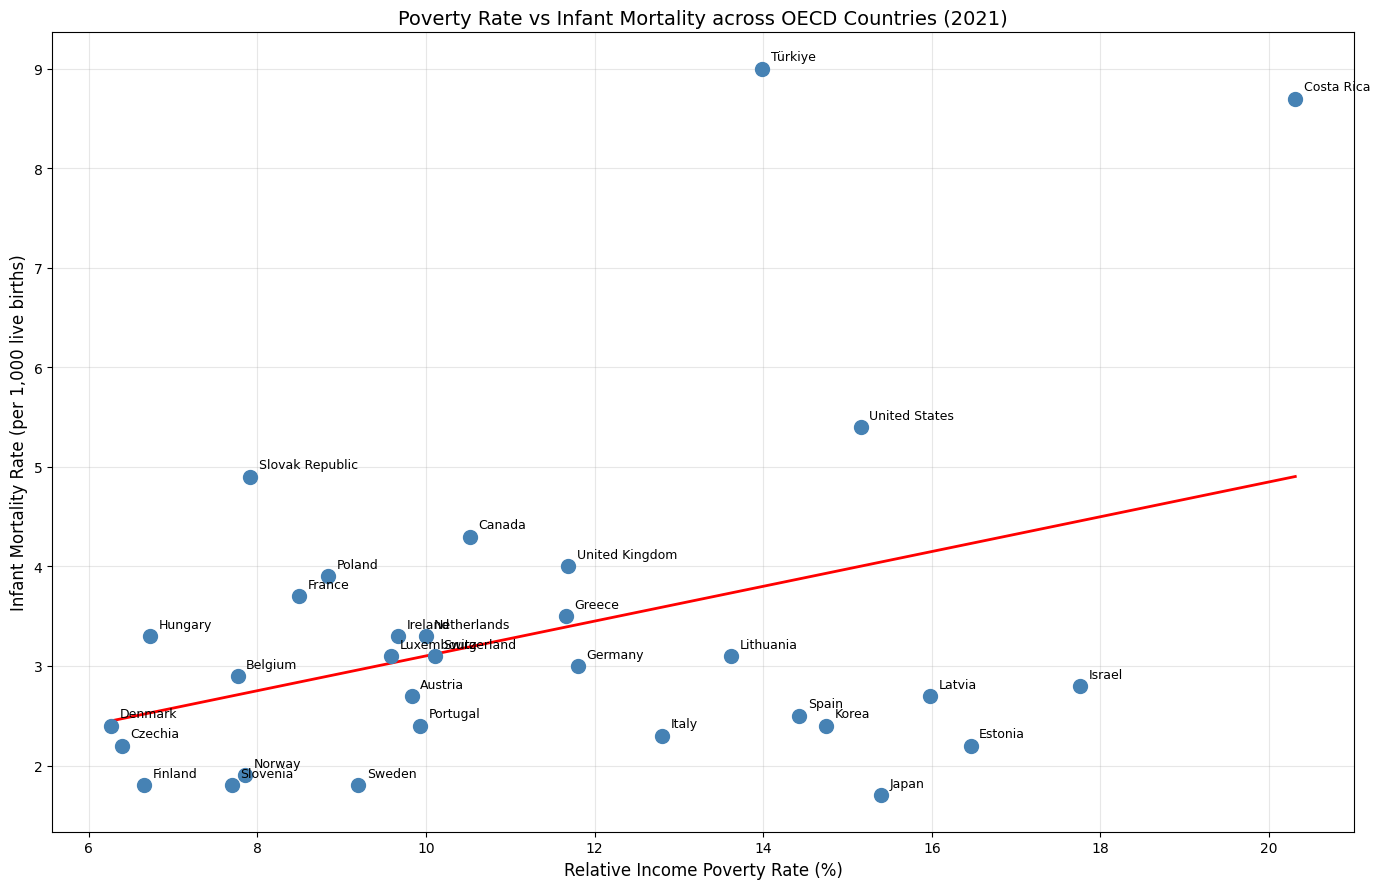

Plot 1 done!


In [27]:
# ---- PLOT 1: Scatter poverty vs infant mortality ----
poverty_2021 = df_analysis[
    (df_analysis['SDG series'] == 'Relative income poverty rate') &
    (df_analysis['TIME_PERIOD'] == 2021)
][['Reference area', 'OBS_VALUE']].rename(columns={'OBS_VALUE': 'poverty'})

health_2021 = df_analysis[
    (df_analysis['SDG series'] == 'Infant mortality rate') &
    (df_analysis['TIME_PERIOD'] == 2021)
][['Reference area', 'OBS_VALUE']].rename(columns={'OBS_VALUE': 'infant_mortality'})

scatter_data = poverty_2021.merge(health_2021, on='Reference area')
r, p = stats.pearsonr(scatter_data['poverty'], scatter_data['infant_mortality'])
print(f"Correlation: r={r:.3f}, p={p:.3f}")

# Plot
fig, ax = plt.subplots(figsize=(14, 9))
ax.scatter(scatter_data['poverty'], scatter_data['infant_mortality'],
           color='steelblue', s=100, zorder=3)

for _, row in scatter_data.iterrows():
    ax.annotate(row['Reference area'],
                (row['poverty'], row['infant_mortality']),
                textcoords="offset points", xytext=(6, 6), fontsize=9)

m, b, _, _, _ = stats.linregress(scatter_data['poverty'], scatter_data['infant_mortality'])
x_line = np.linspace(scatter_data['poverty'].min(), scatter_data['poverty'].max(), 100)
ax.plot(x_line, m*x_line + b, color='red', linewidth=2)

ax.set_xlabel("Relative Income Poverty Rate (%)", fontsize=12)
ax.set_ylabel("Infant Mortality Rate (per 1,000 live births)", fontsize=12)
ax.set_title("Poverty Rate vs Infant Mortality across OECD Countries (2021)", fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figure1_scatter.png", dpi=300, bbox_inches='tight')
plt.show()
print("Plot 1 done!")

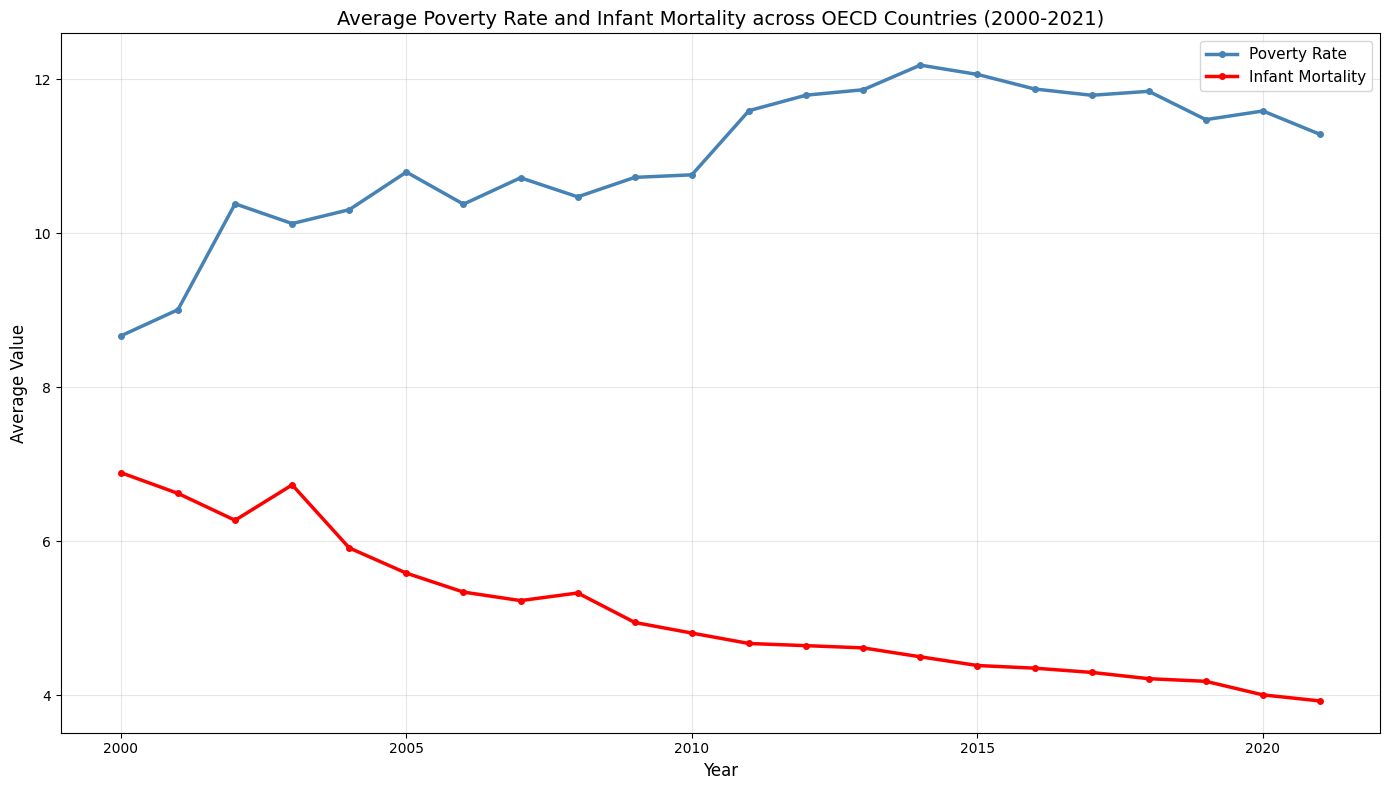

Plot 2 done!


In [28]:
# ---- PLOT 2: Trend over time ----
poverty_trend = df_analysis[
    df_analysis['SDG series'] == 'Relative income poverty rate'
].groupby('TIME_PERIOD')['OBS_VALUE'].mean()

health_trend = df_analysis[
    df_analysis['SDG series'] == 'Infant mortality rate'
].groupby('TIME_PERIOD')['OBS_VALUE'].mean()

fig, ax = plt.subplots(figsize=(14, 8))
ax.plot(poverty_trend.index, poverty_trend.values,
        color='steelblue', linewidth=2.5, label='Poverty Rate',
        marker='o', markersize=4)
ax.plot(health_trend.index, health_trend.values,
        color='red', linewidth=2.5, label='Infant Mortality',
        marker='o', markersize=4)

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Average Value", fontsize=12)
ax.set_title("Average Poverty Rate and Infant Mortality across OECD Countries (2000-2021)", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figure2_trend.png", dpi=300, bbox_inches='tight')
plt.show()
print("Plot 2 done!")

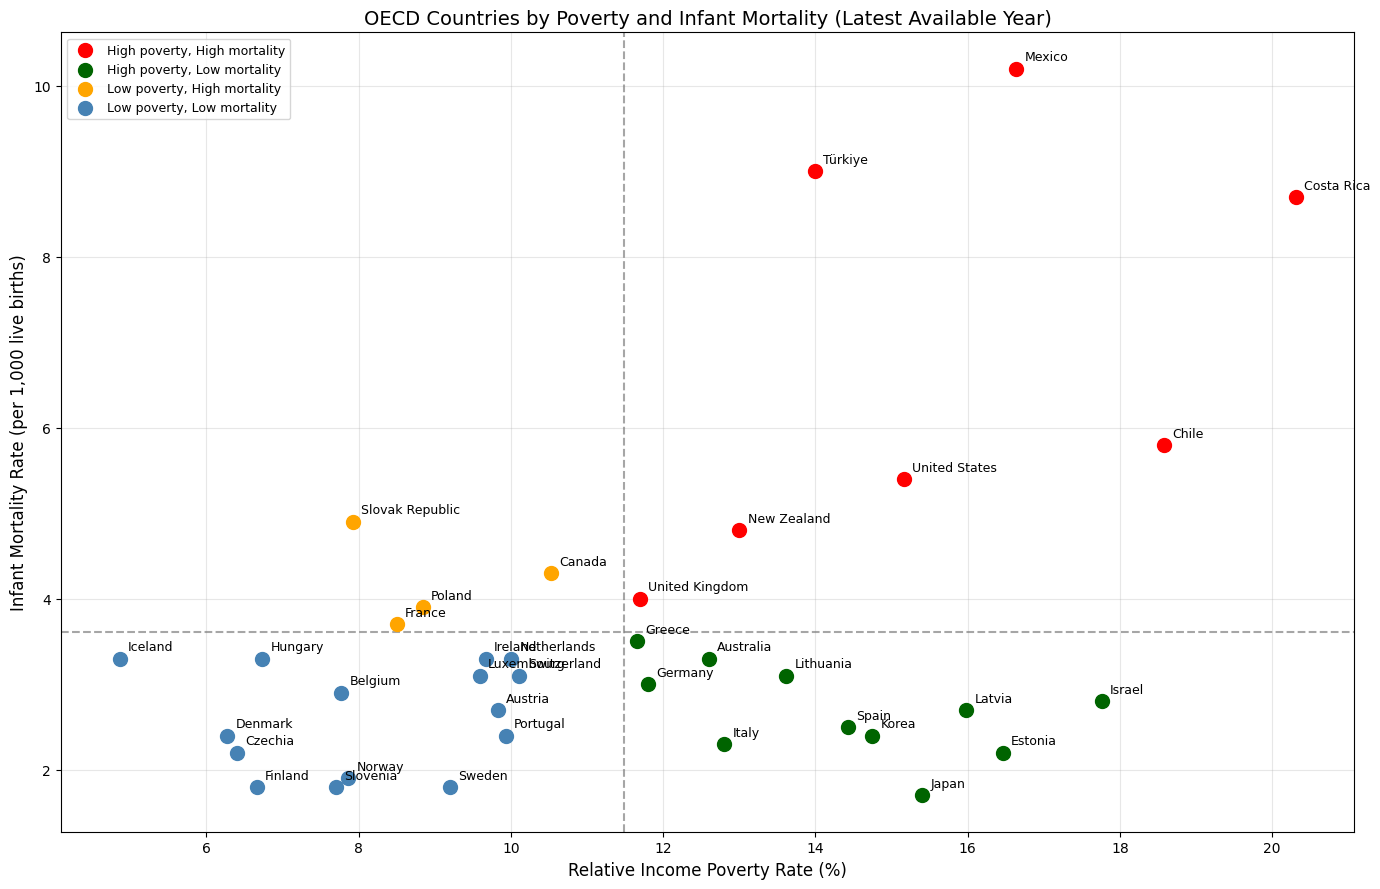

Plot 3 done!


In [30]:
# ---- PLOT 3: Quadrant analysis ----
poverty_latest = df_analysis[
    df_analysis['SDG series'] == 'Relative income poverty rate'
].groupby('Reference area')['OBS_VALUE'].last().reset_index()
poverty_latest.columns = ['Reference area', 'poverty']

health_latest = df_analysis[
    df_analysis['SDG series'] == 'Infant mortality rate'
].groupby('Reference area')['OBS_VALUE'].last().reset_index()
health_latest.columns = ['Reference area', 'infant_mortality']

outlier_data = poverty_latest.merge(health_latest, on='Reference area')
avg_pov = outlier_data['poverty'].mean()
avg_mort = outlier_data['infant_mortality'].mean()

def categorise(row):
    if row['poverty'] < avg_pov and row['infant_mortality'] < avg_mort:
        return 'Low poverty, Low mortality'
    elif row['poverty'] > avg_pov and row['infant_mortality'] > avg_mort:
        return 'High poverty, High mortality'
    elif row['poverty'] < avg_pov and row['infant_mortality'] > avg_mort:
        return 'Low poverty, High mortality'
    elif row['poverty'] > avg_pov and row['infant_mortality'] < avg_mort:
        return 'High poverty, Low mortality'
    return 'Average'

outlier_data['category'] = outlier_data.apply(categorise, axis=1)

colors = {
    'Low poverty, Low mortality': 'steelblue',
    'High poverty, High mortality': 'red',
    'Low poverty, High mortality': 'orange',
    'High poverty, Low mortality': 'darkgreen',
    'Average': 'gray'
}

fig, ax = plt.subplots(figsize=(14, 9))
for cat, grp in outlier_data.groupby('category'):
    ax.scatter(grp['poverty'], grp['infant_mortality'],
               color=colors[cat], label=cat, s=100, zorder=3)
    for _, row in grp.iterrows():
        ax.annotate(row['Reference area'],
                    (row['poverty'], row['infant_mortality']),
                    textcoords="offset points", xytext=(6, 6), fontsize=9)

ax.axvline(avg_pov, color='gray', linestyle='--', alpha=0.7)
ax.axhline(avg_mort, color='gray', linestyle='--', alpha=0.7)
ax.set_xlabel("Relative Income Poverty Rate (%)", fontsize=12)
ax.set_ylabel("Infant Mortality Rate (per 1,000 live births)", fontsize=12)
ax.set_title("OECD Countries by Poverty and Infant Mortality (Latest Available Year)", fontsize=14)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figure3_quadrant.png", dpi=300, bbox_inches='tight')
plt.show()
print("Plot 3 done!")

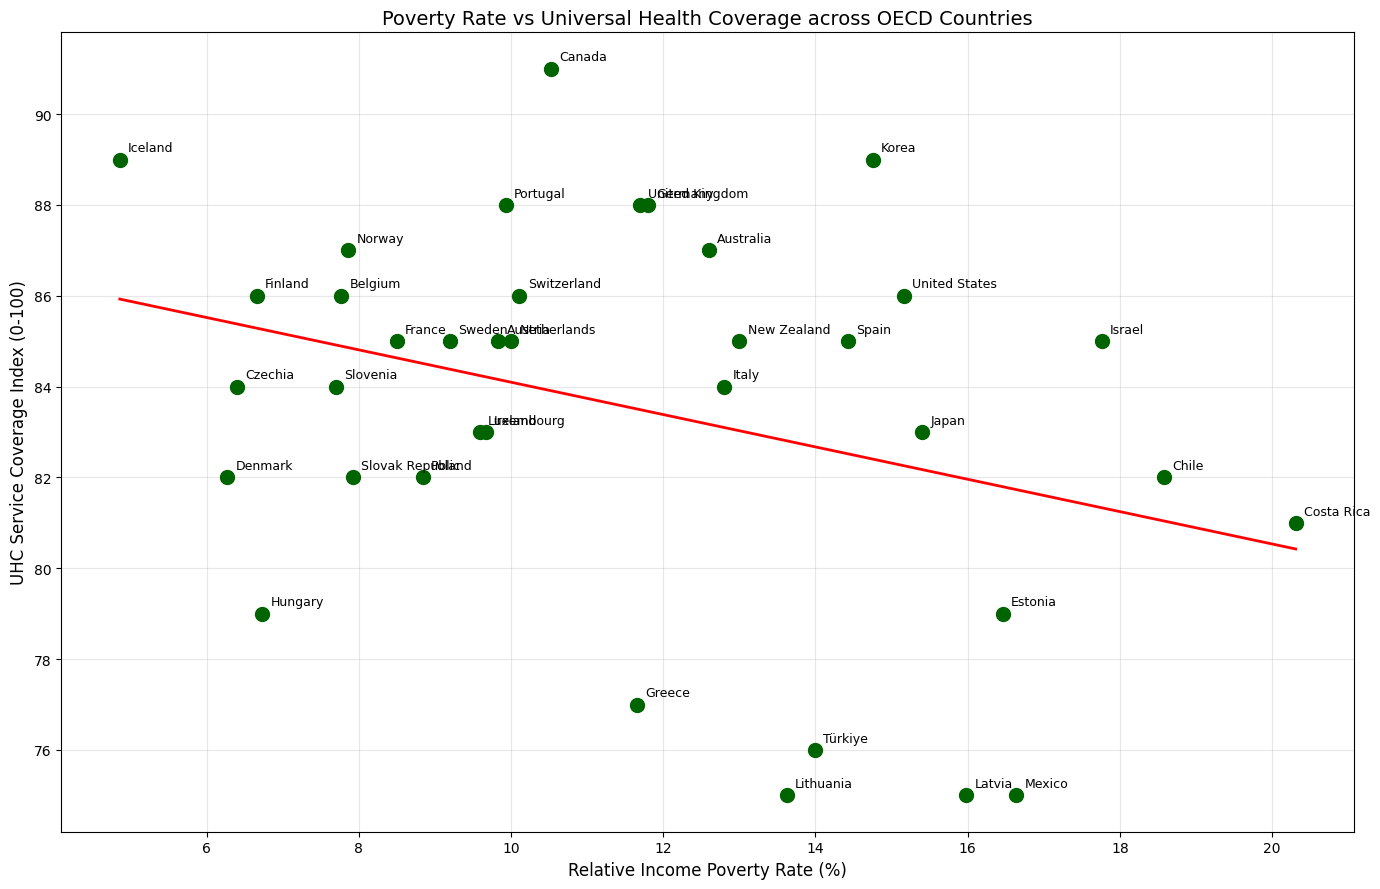

Plot 4 done!


In [31]:
# ---- PLOT 4: UHC vs Poverty ----
uhc_latest = df_analysis[
    df_analysis['SDG series'] == 'Universal health coverage (UHC) service coverage index'
].groupby('Reference area')['OBS_VALUE'].last().reset_index()
uhc_latest.columns = ['Reference area', 'uhc']

poverty_latest2 = df_analysis[
    df_analysis['SDG series'] == 'Relative income poverty rate'
].groupby('Reference area')['OBS_VALUE'].last().reset_index()
poverty_latest2.columns = ['Reference area', 'poverty']

uhc_data = poverty_latest2.merge(uhc_latest, on='Reference area')

fig, ax = plt.subplots(figsize=(14, 9))
ax.scatter(uhc_data['poverty'], uhc_data['uhc'],
           color='darkgreen', s=100, zorder=3)

for _, row in uhc_data.iterrows():
    ax.annotate(row['Reference area'],
                (row['poverty'], row['uhc']),
                textcoords="offset points", xytext=(6, 6), fontsize=9)

m, b, _, _, _ = stats.linregress(uhc_data['poverty'], uhc_data['uhc'])
x_line = np.linspace(uhc_data['poverty'].min(), uhc_data['poverty'].max(), 100)
ax.plot(x_line, m*x_line + b, color='red', linewidth=2)

ax.set_xlabel("Relative Income Poverty Rate (%)", fontsize=12)
ax.set_ylabel("UHC Service Coverage Index (0-100)", fontsize=12)
ax.set_title("Poverty Rate vs Universal Health Coverage across OECD Countries", fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figure4_uhc.png", dpi=300, bbox_inches='tight')
plt.show()
print("Plot 4 done!")